# Data Cleaning & Visualization Project

Internship task: clean a raw dataset, process it, and visualize insights using Pandas, Matplotlib, and Seaborn.

## 1. Load Raw Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/raw_sales_data.csv")
print("Shape:", df.shape)
df.head()

Shape: (1230, 8)


,order_id,order_date,category,region,payment_mode,units_sold,unit_price,revenue
0,1508,06/03/2025,SPORTS,east,Net Banking,17.0,300.47,5107.99
1,1741,2025-08-13,Clothing,north,Credit Card,22.0,367.09,8075.98
2,1279,26-Mar-2025,Electronics,North,Cash,8.0,12.12,96.96
3,1930,10/10/2025,Electronics,WEST,Debit Card,20.0,165.54,3310.80
4,1633,2025-07-11,Sports,north,Cash,5.0,NaN,NaN


## 2. Explore Data Quality Issues

In [2]:
print("Missing values:\n", df.isna().sum())
print("\nDuplicate order_ids:", df['order_id'].duplicated().sum())
print("\nSample of messy text values:", df['category'].unique()[:6])

Missing values:
 order_id         0
order_date       0
category         0
region          51
payment_mode    38
units_sold      25
unit_price      73
revenue         94
dtype: int64

Duplicate order_ids: 30

Sample of messy text values: <StringArray>
['SPORTS', 'Clothing', 'Electronics', '  Electronics  ', '  Sports  ',
 'Sports']
Length: 6, dtype: str


## 3. Clean the Data
- Remove duplicates
- Standardize text
- Parse mixed date formats
- Impute missing values
- Cap outliers with the IQR method

In [3]:
df = df.drop_duplicates(subset=["order_id"], keep="first")

for col in ["category", "region", "payment_mode"]:
    df[col] = df[col].astype(str).str.strip().str.title().replace("Nan", np.nan)

KNOWN_FORMATS = ["%Y-%m-%d", "%d/%m/%Y", "%d-%b-%Y", "%m/%d/%Y"]
def parse_mixed_dates(series):
    result = pd.Series(pd.NaT, index=series.index, dtype="datetime64[ns]")
    remaining = series.copy()
    for fmt in KNOWN_FORMATS:
        parsed = pd.to_datetime(remaining, format=fmt, errors="coerce")
        result = result.fillna(parsed)
        remaining = remaining.where(parsed.isna())
    return result

df["order_date"] = parse_mixed_dates(df["order_date"].astype(str))

df["unit_price"] = df.groupby("category")["unit_price"].transform(lambda x: x.fillna(x.median()))
df["units_sold"] = df.groupby("category")["units_sold"].transform(lambda x: x.fillna(x.median()))
for col in ["region", "payment_mode"]:
    df[col] = df[col].fillna(df[col].mode()[0])

df = df.dropna(subset=["order_date"])

def cap_outliers_iqr(series, factor=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - factor * iqr, q3 + factor * iqr
    return series.clip(lower=max(lower, 0), upper=upper)

for col in ["units_sold", "unit_price"]:
    df[col] = cap_outliers_iqr(df[col])

df["revenue"] = (df["units_sold"] * df["unit_price"]).round(2)
df["month"] = df["order_date"].dt.month_name()
df["units_sold"] = df["units_sold"].round().astype(int)

print("Clean shape:", df.shape)
df.head()

Clean shape: (1200, 9)


,order_id,order_date,category,region,payment_mode,units_sold,unit_price,revenue,month
0,1508,2025-03-06,Sports,East,Net Banking,17,300.47,5107.99,March
1,1741,2025-08-13,Clothing,North,Credit Card,22,367.09,8075.98,August
2,1279,2025-03-26,Electronics,North,Cash,8,12.12,96.96,March
3,1930,2025-10-10,Electronics,West,Debit Card,20,165.54,3310.80,October
4,1633,2025-07-11,Sports,North,Cash,5,241.29,1206.45,July


## 4. Visualize Insights

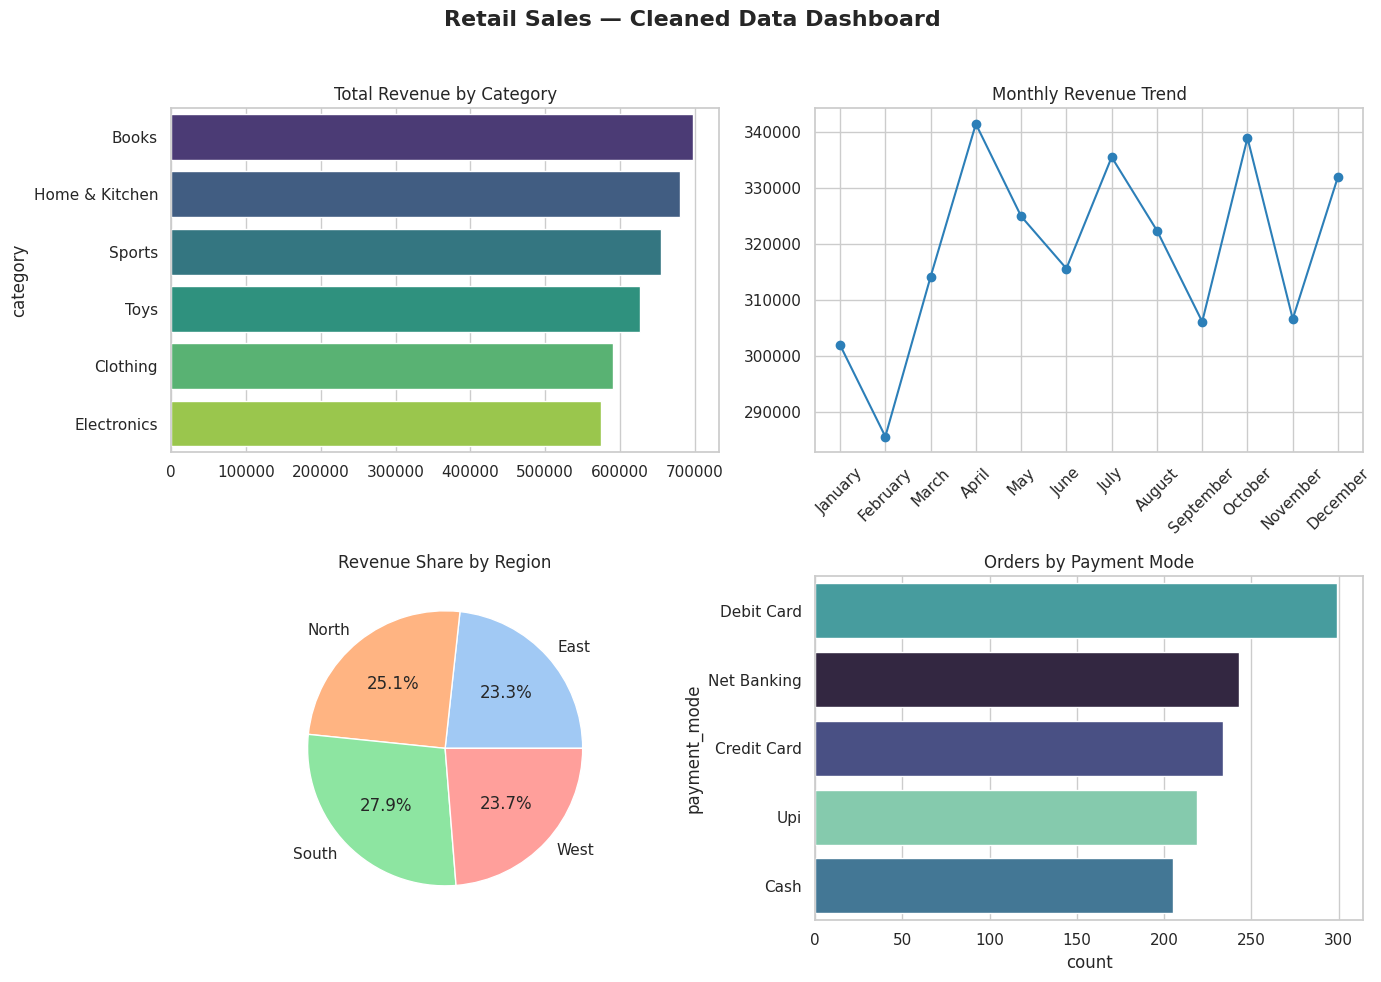

In [4]:
month_order = ["January","February","March","April","May","June","July","August","September","October","November","December"]
df["month"] = pd.Categorical(df["month"], categories=month_order, ordered=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Retail Sales — Cleaned Data Dashboard", fontsize=16, fontweight="bold")

cat_rev = df.groupby("category")["revenue"].sum().sort_values(ascending=False)
sns.barplot(x=cat_rev.values, y=cat_rev.index, ax=axes[0,0], hue=cat_rev.index, legend=False, palette="viridis")
axes[0,0].set_title("Total Revenue by Category")

monthly_rev = df.groupby("month", observed=True)["revenue"].sum()
axes[0,1].plot(monthly_rev.index, monthly_rev.values, marker="o", color="#2c7fb8")
axes[0,1].set_title("Monthly Revenue Trend")
axes[0,1].tick_params(axis="x", rotation=45)

region_rev = df.groupby("region")["revenue"].sum()
axes[1,0].pie(region_rev.values, labels=region_rev.index, autopct="%1.1f%%", colors=sns.color_palette("pastel"))
axes[1,0].set_title("Revenue Share by Region")

sns.countplot(data=df, y="payment_mode", order=df["payment_mode"].value_counts().index, ax=axes[1,1], hue="payment_mode", legend=False, palette="mako")
axes[1,1].set_title("Orders by Payment Mode")

plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

## 5. Category Summary Table

In [5]:
summary = df.groupby("category").agg(
    total_orders=("order_id","count"),
    total_units=("units_sold","sum"),
    total_revenue=("revenue","sum"),
    avg_order_value=("revenue","mean"),
).round(2).sort_values("total_revenue", ascending=False)
summary

,total_orders,total_units,total_revenue,avg_order_value
category,,,,
Books,207,2824,697670.27,3370.39
Home & Kitchen,190,2658,680230.84,3580.16
Sports,204,2639,655532.56,3213.39
Toys,199,2611,626294.61,3147.21
Clothing,190,2234,590389.90,3107.32
Electronics,210,2359,575009.96,2738.14


## 6. Save Clean Data

In [6]:
df.to_csv("../data/clean_sales_data.csv", index=False)
print("Saved cleaned dataset.")

Saved cleaned dataset.
